# Calculating Gene Program (GP) Importance Scores

This tutorial demonstrates how to calculate and analyze Tripso **Gene Program (GP) importance scores** from the GPLearner model. GP importance scores quantify how much each gene program contributes to a cell's identity, enabling:

## What are GP Importance Scores?

GP importance scores are computed using an **ablation approach**:
- The model is run with each gene program individually masked/removed
- We compute the cosine similarity between perturbed cell representation (output of the model with the masked GP) and the original cell representation.
- The output is (1 - cosine similarity with control cell) such that higher scores = more critical for the cell representation

## Prerequisites
- Completed model training with GP ablation enabled (see training tutorials)
- Ablation results saved in `output_global/ablation/with_gp_ablation/`

In [1]:
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load GP Importance Scores

The ablation analysis generates AnnData objects where:
- **Cells (observations)**: Individual cells from your dataset
- **Variables (features)**: Gene programs (e.g., `GP_GATA1`, `GP_LMO2`, etc.)
- **Data matrix (X)**: GP importance scores for each cell-GP.

### Data Loading Options

**Option 1 (Recommended for publication)**: Combine multiple training runs
- Train model 3 times with different random seeds
- Average GP importance scores across runs. While patterns across runs are broadly consistentt, this increaases robustness and reduces noise from stochastic training effects
- (this was the approach for the original Tripso manuscript)

**Option 2 (Tutorial)**: Single run for simplicity
- Faster to execute
- Suitable for exploratory analysis

In [2]:
# Load GP importance scores from ablation analysis
# The ablation process masks each GP and measures reconstruction loss change

# Option 1: Load and combine all data splits
train = sc.read_h5ad('output_global/ablation/with_gp_ablation/train_set.h5ad')
val = sc.read_h5ad('output_global/ablation/with_gp_ablation/val_set.h5ad')
test = sc.read_h5ad('output_global/ablation/with_gp_ablation/test_set.h5ad')
adata = ad.concat([train, val, test])

# Option 2: Load only test set for faster tutorial execution (commented out)
# adata = sc.read_h5ad('output_global/ablation/with_gp_ablation/test_set.h5ad')

adata

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 79583 × 33
    obs: 'length', 'runid_mrna_sample', 'sorting', 'biological_replicate_labID', 'age', 'sex', 'tissue', 'age_general', 'phase', 'cell_type', 'donor_tissue', 'donor', 'source', 'tissue_source', 'n_counts', 'study', 'idx', 'batch_key', 'cell_type_id', 'source_id', 'batch_key_id'

## 3. Case Study: Dendritic Cell Subtypes

Dendritic cells (DCs) are immune cells with distinct subtypes that have different functional roles:
- **pDC (plasmacytoid DC)**: Specialize in antiviral responses, produce type I interferon
- **cDC1 (conventional DC type 1)**: Cross-present antigens, activate CD8+ T cells
- **cDC2 (conventional DC type 2)**: Present antigens to CD4+ T cells, Th2 responses

**Goal**: Identify which gene programs distinguish these functionally distinct DC subtypes.
In the next steps, we will look at which **genes** drive these differences. 

### 3.1 Filter to Dendritic Cell Subtypes

In [3]:
# Subset to three dendritic cell subtypes for differential analysis
dc = adata[
    adata.obs['cell_type'].isin(['22_pDC',    # Plasmacytoid dendritic cells
                                  '24_cDC1',   # Conventional DC type 1
                                  '25_cDC2',   # Conventional DC type 2
                                 ])
]
dc

View of AnnData object with n_obs × n_vars = 2657 × 33
    obs: 'length', 'runid_mrna_sample', 'sorting', 'biological_replicate_labID', 'age', 'sex', 'tissue', 'age_general', 'phase', 'cell_type', 'donor_tissue', 'donor', 'source', 'tissue_source', 'n_counts', 'study', 'idx', 'batch_key', 'cell_type_id', 'source_id', 'batch_key_id'

## 4. Differential GP Analysis

Now we perform **differential gene program analysis** - analogous to differential gene expression (DGE), but at the gene program level.

### 4.1 Rank Gene Programs by Cell Type

We use Scanpy's `rank_genes_groups` function, which:
- Treats GP importance scores like gene expression values
- For each cell type, identifies significantly enriched/depleted GPs
- Uses statistical tests (default: t-test with overestimation correction)
- Returns ranked lists with log fold changes and p-values

Since the data matrix contains GP importance scores (not gene expression), this identifies GPs that are differentially important across cell types.

In [4]:
# Perform differential GP analysis across dendritic cell subtypes
# This identifies which GPs are significantly more/less important in each subtype
sc.tl.rank_genes_groups(
    dc,
    groupby='cell_type',  # Compare GP importance across cell types
)

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:645: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


### 4.2 Extract Results for cDC1

Retrieve the ranked list of GPs for conventional DC type 1 cells.

**Interpretation**:
- **Positive logfoldchanges**: GPs more important in cDC1 vs. other DC types
- **Negative logfoldchanges**: GPs less important in cDC1
- **pvals_adj < 0.05**: Statistically significant differences

In [10]:
# Get differential GP results for cDC1
cdc1 = sc.get.rank_genes_groups_df(dc, group='24_cDC1')

# Show top GPs enriched in cDC1 (positive log fold change, significant)
cdc1.head()

,names,scores,logfoldchanges,pvals,pvals_adj
0,GP_NFYB,3.263780,0.638305,0.001364,0.011252
1,GP_DDIT3,2.934011,0.297084,0.003856,0.021148
2,GP_E2F4,2.517618,0.129425,0.012821,0.047011
3,GP_NR2C2,2.440947,1.808814,0.015822,0.052214
4,GP_KLF1,2.258665,0.598796,0.025243,0.075730


### 4.3 Extract Results for cDC2

In [6]:
# Get differential GP results for cDC2
cdc2 = sc.get.rank_genes_groups_df(dc, group='25_cDC2')

# Display top results
cdc2.head()

,names,scores,logfoldchanges,pvals,pvals_adj
0,GP_NFYB,18.875824,1.601299,3.961359e-74,3.268121e-73
1,GP_IRF1,15.479861,3.178530,2.227777e-50,1.050238e-49
2,GP_DDIT3,12.730206,0.597047,4.458851e-36,1.839276e-35
3,GP_SNAI2,9.012336,1.807199,5.730322e-19,1.575838e-18
4,GP_PRDM1,7.543957,2.235339,7.795027e-14,1.978738e-13


### 4.4 Extract Results for pDC

In [7]:
# Get differential GP results for plasmacytoid DC
pdc = sc.get.rank_genes_groups_df(dc, group='22_pDC')

# Display top results
pdc.head()

,names,scores,logfoldchanges,pvals,pvals_adj
0,GP_IKZF1,36.071156,1.577026,3.303918e-226,1.090293e-224
1,GP_MYB,22.618654,0.943716,8.682453e-100,9.550698e-99
2,GP_JUND,21.907064,3.571640,4.964633e-93,4.095822e-92
3,GP_E2F4,17.225775,0.393599,4.519695e-63,2.982999e-62
4,GP_GATA2,16.128462,2.138938,2.019269e-54,1.110598e-53


## 5. Visualize GP Importance Distributions

To better understand how GP importance varies across cell types, we create box plots showing the distribution of importance scores.

In [8]:
def make_barplot(pert_data, gp, fig_size=(5, 5), save=None):
    """
    Create box plot showing GP importance score distribution across cell types.
    
    Parameters:
    -----------
    pert_data : AnnData
        Data containing GP importance scores and cell type annotations
    gp : str
        Gene program name (e.g., 'GP_GATA1')
    fig_size : tuple
        Figure dimensions (width, height)
    save : str, optional
        File path to save figure
    """
    # Color palette (may need customization based on your cell types)
    colors = [
        'bisque',       # Color for first cell type
        'lightcoral',   # Color for second cell type
        'lightblue',    # Color for third cell type
        'navy',         # Color for fourth cell type (if applicable)
    ]
    
    # Extract GP importance scores and add to observations for plotting
    # This converts the GP column from the data matrix to a metadata column
    pert_data.obs[gp] = pert_data[:, pert_data.var.index == gp].X.toarray().flatten()

    # Create box plot
    plt.figure(figsize=fig_size)
    ax = sns.boxplot(
        data=pert_data.obs,
        y=gp,                                           # GP importance on y-axis
        x="cell_type",                                  # Cell types on x-axis
        order=pert_data.obs['cell_type'].cat.categories, # Preserve categorical order
        palette=colors
    )

    # Formatting
    plt.xticks(rotation=90)
    plt.xlabel("Cell type")
    plt.ylabel(f"{gp} importance score")
    plt.title(gp)
    plt.tight_layout(rect=[0, 0, 0.85, 1])  
    
    if save:
        plt.savefig(save)

    plt.show()

/tmp/ipykernel_3288871/3037720715.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_3288871/3037720715.py:30: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  ax = sns.boxplot(


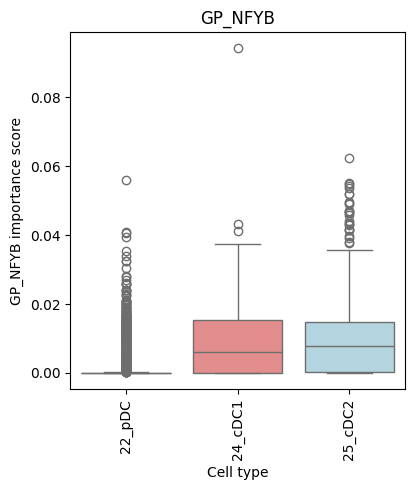

/tmp/ipykernel_3288871/3037720715.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_3288871/3037720715.py:30: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  ax = sns.boxplot(


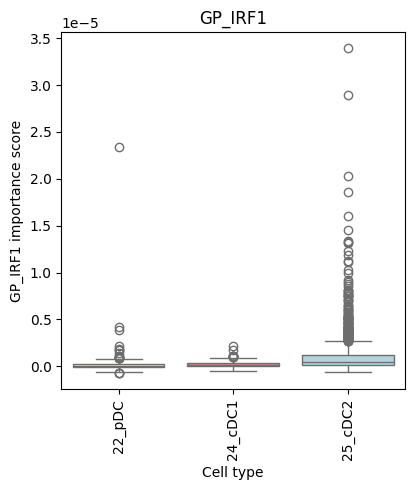

/tmp/ipykernel_3288871/3037720715.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_3288871/3037720715.py:30: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  ax = sns.boxplot(


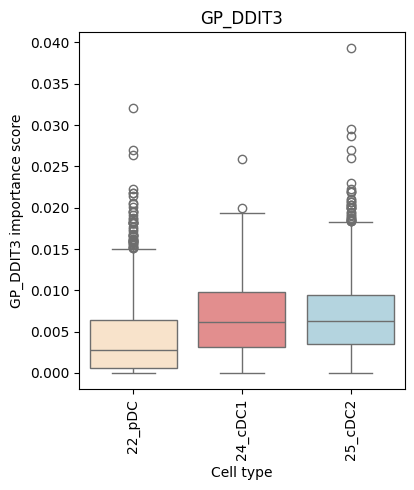

/tmp/ipykernel_3288871/3037720715.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_3288871/3037720715.py:30: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  ax = sns.boxplot(


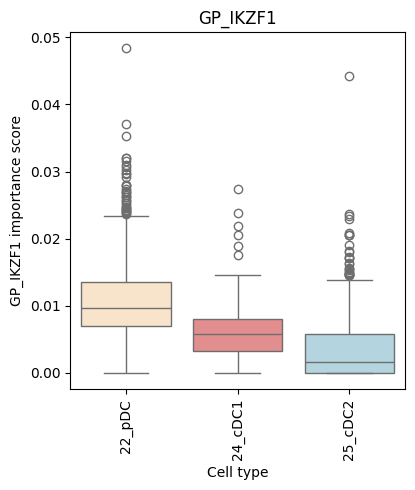

In [11]:
# Visualize GP importance distributions for example gene programs
# These GPs were selected based on known roles in hematopoiesis
for gp in ['GP_NFYB', 'GP_IRF1', 'GP_DDIT3', 'GP_IKZF1']:
    make_barplot(dc, gp)